<a href="https://colab.research.google.com/github/Carlos-A-Palomares/mis433/blob/main/IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv', header=0)

imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [5]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()

imdb["Released_Year"].value_counts()


,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [6]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.

imdb[imdb["Released_Year"].astype(str).str.len() != 4]


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [7]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value

imdb.loc[imdb["Series_Title"] == "Apollo 13", "Released_Year"] = "1995"
imdb.loc[imdb["Series_Title"] == "Apollo 13", "Certificate"] = "PG"

imdb[imdb["Series_Title"] == "Apollo 13"]


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,1995,PG,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [8]:
# Change the data type of "Released_Year" to int

imdb["Released_Year"] = imdb["Released_Year"].astype(int)
imdb["Released_Year"].dtype


dtype('int64')

In [9]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

recent_high_rated = imdb[(imdb["Released_Year"] >= 2010) & (imdb["IMDB_Rating"] >= 8.5)]
recent_high_rated[["Series_Title", "Released_Year", "Certificate", "Gross"]].sort_values("Gross", ascending=False)


,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [10]:
# Does the sorting result looks right to you? What's the problem?

print("No, the sorting does not look right because Gross is stored as text with commas, not as numbers.")
print(imdb["Gross"].dtype)


No, the sorting does not look right because Gross is stored as text with commas, not as numbers.
object


In [11]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe

imdb["Gross"] = imdb["Gross"].astype(str).str.replace(",", "", regex=False)
imdb["Gross"] = imdb["Gross"].astype(float)
imdb["Gross"].dtype


dtype('float64')

In [12]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

recent_high_rated = imdb[(imdb["Released_Year"] >= 2010) & (imdb["IMDB_Rating"] >= 8.5)]
recent_high_rated[["Series_Title", "Released_Year", "Certificate", "Gross"]].sort_values("Gross", ascending=False)


,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [13]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe

imdb["Runtime_min"] = imdb["Runtime"].str.replace(" min", "", regex=False)
imdb["Runtime_min"] = imdb["Runtime_min"].astype(int)
imdb[["Runtime", "Runtime_min"]].head()


,Runtime,Runtime_min
0,142 min,142
1,175 min,175
2,152 min,152
3,202 min,202
4,96 min,96


In [14]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year

current_year = pd.Timestamp.today().year
imdb["Age_Year"] = current_year - imdb["Released_Year"]
imdb[["Series_Title", "Released_Year", "Age_Year"]].head()


,Series_Title,Released_Year,Age_Year
0,The Shawshank Redemption,1994,32
1,The Godfather,1972,54
2,The Dark Knight,2008,18
3,The Godfather: Part II,1974,52
4,12 Angry Men,1957,69


In [15]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.

imdb["Decade"] = (imdb["Released_Year"] // 10) * 10
imdb[["Series_Title", "Released_Year", "Decade"]].head()


,Series_Title,Released_Year,Decade
0,The Shawshank Redemption,1994,1990
1,The Godfather,1972,1970
2,The Dark Knight,2008,2000
3,The Godfather: Part II,1974,1970
4,12 Angry Men,1957,1950


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

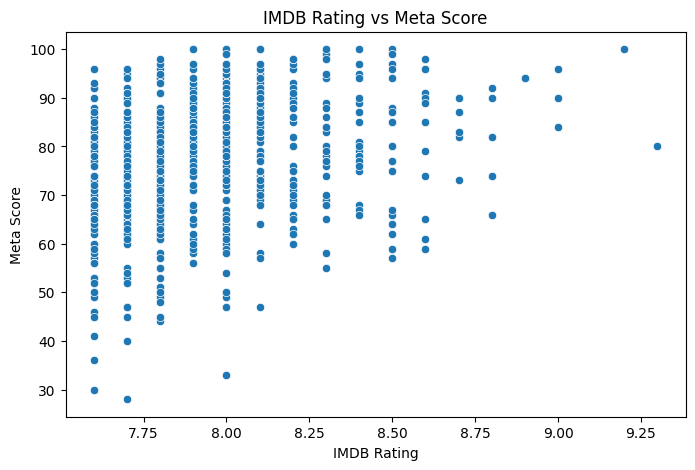

The chart suggests that movies with higher IMDB ratings often also have higher Meta scores.
The relationship is positive, but it is not perfect because some movies have very different scores.


In [17]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.

plt.figure(figsize=(8, 5))
sns.scatterplot(data=imdb, x="IMDB_Rating", y="Meta_score")
plt.title("IMDB Rating vs Meta Score")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()

print("The chart suggests that movies with higher IMDB ratings often also have higher Meta scores.")
print("The relationship is positive, but it is not perfect because some movies have very different scores.")


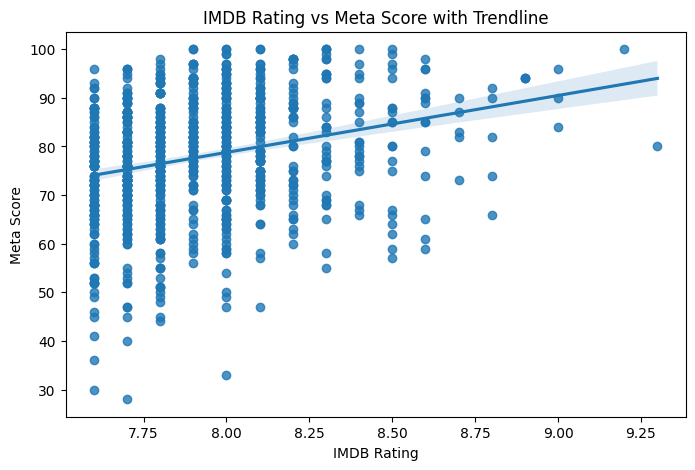

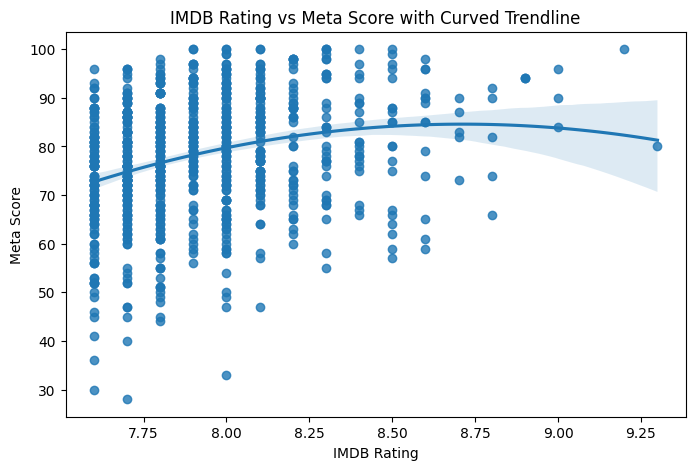

In [18]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.

plt.figure(figsize=(8, 5))
sns.regplot(data=imdb, x="IMDB_Rating", y="Meta_score", order=1)
plt.title("IMDB Rating vs Meta Score with Trendline")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(data=imdb, x="IMDB_Rating", y="Meta_score", order=2)
plt.title("IMDB Rating vs Meta Score with Curved Trendline")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()


In [19]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.

score_gap = imdb.copy()
score_gap["Score_Difference"] = (score_gap["IMDB_Rating"] * 10) - score_gap["Meta_score"]
score_gap[["Series_Title", "IMDB_Rating", "Meta_score", "Score_Difference"]].sort_values("Score_Difference", ascending=False).head(10)


,Series_Title,IMDB_Rating,Meta_score,Score_Difference
788,I Am Sam,7.7,28.0,49.0
356,Tropa de Elite,8.0,33.0,47.0
942,The Butterfly Effect,7.6,30.0,46.0
917,Seven Pounds,7.6,36.0,40.0
735,Kai po che!,7.7,40.0,37.0
957,Fear and Loathing in Las Vegas,7.6,41.0,35.0
272,Pink Floyd: The Wall,8.1,47.0,34.0
648,The Boondock Saints,7.8,44.0,34.0
397,Bound by Honor,8.0,47.0,33.0
677,Predator,7.8,45.0,33.0


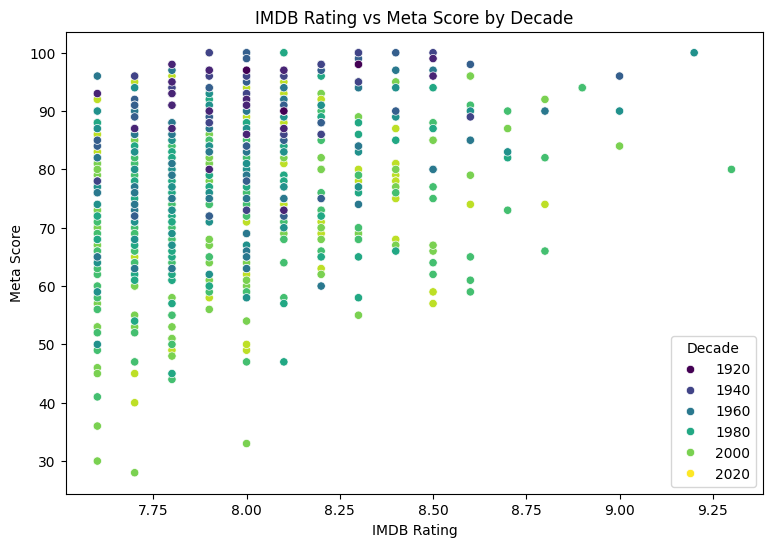

In [20]:
# In the scatterplot, use color to distinguish movies from different decades.

plt.figure(figsize=(9, 6))
sns.scatterplot(data=imdb, x="IMDB_Rating", y="Meta_score", hue="Decade", palette="viridis")
plt.title("IMDB Rating vs Meta Score by Decade")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.legend(title="Decade")
plt.show()


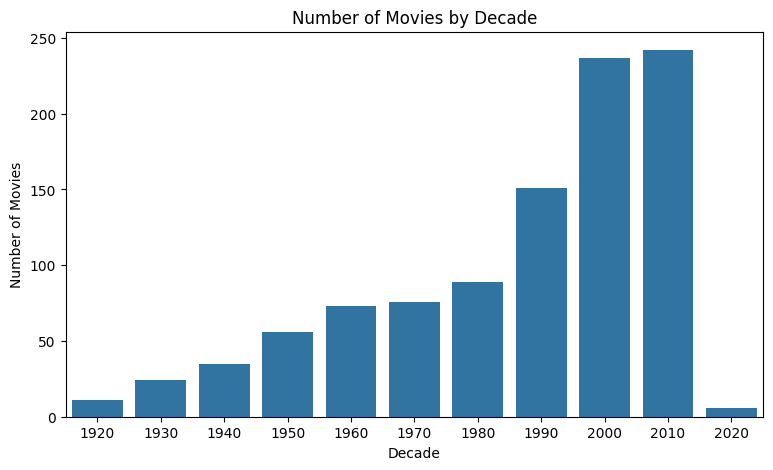

In [21]:
# Create a chart that shows how many movies fall in each decade.

decade_counts = imdb["Decade"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=decade_counts.index, y=decade_counts.values)
plt.title("Number of Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.show()


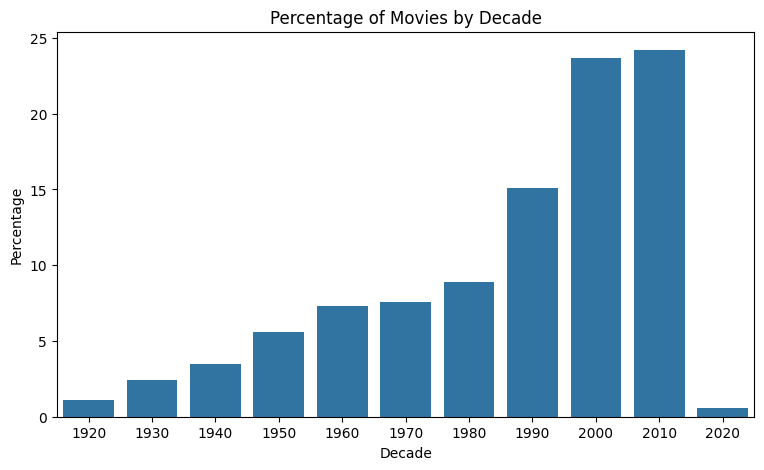

In [22]:
# Create a chart that shows the percentage of movies in each decade.

decade_percent = imdb["Decade"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=decade_percent.index, y=decade_percent.values)
plt.title("Percentage of Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Percentage")
plt.show()


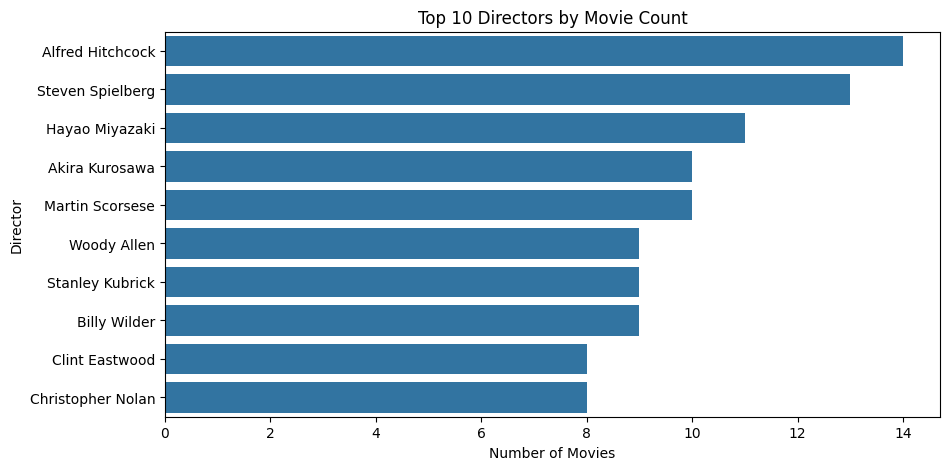

In [23]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.

top_directors = imdb["Director"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors by Movie Count")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()


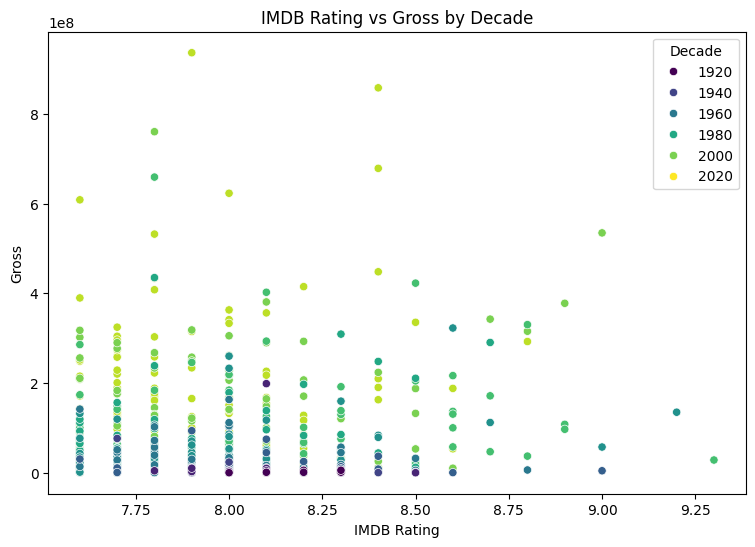

The chart shows that a higher IMDB rating does not always mean a higher gross revenue.
Some movies earned very high gross revenue even when their ratings are not the highest in the dataset.


In [24]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.

plt.figure(figsize=(9, 6))
sns.scatterplot(data=imdb, x="IMDB_Rating", y="Gross", hue="Decade", palette="viridis")
plt.title("IMDB Rating vs Gross by Decade")
plt.xlabel("IMDB Rating")
plt.ylabel("Gross")
plt.legend(title="Decade")
plt.show()

print("The chart shows that a higher IMDB rating does not always mean a higher gross revenue.")
print("Some movies earned very high gross revenue even when their ratings are not the highest in the dataset.")


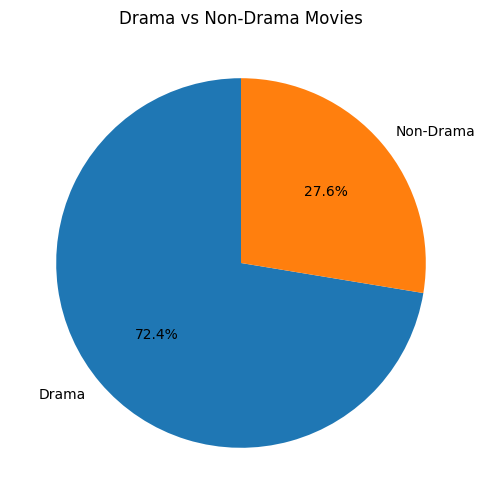

In [25]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.

imdb["Drama"] = imdb["Genre"].str.contains("Drama")
drama_counts = imdb["Drama"].value_counts()
labels = ["Drama", "Non-Drama"]

plt.figure(figsize=(6, 6))
plt.pie(drama_counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Drama vs Non-Drama Movies")
plt.show()


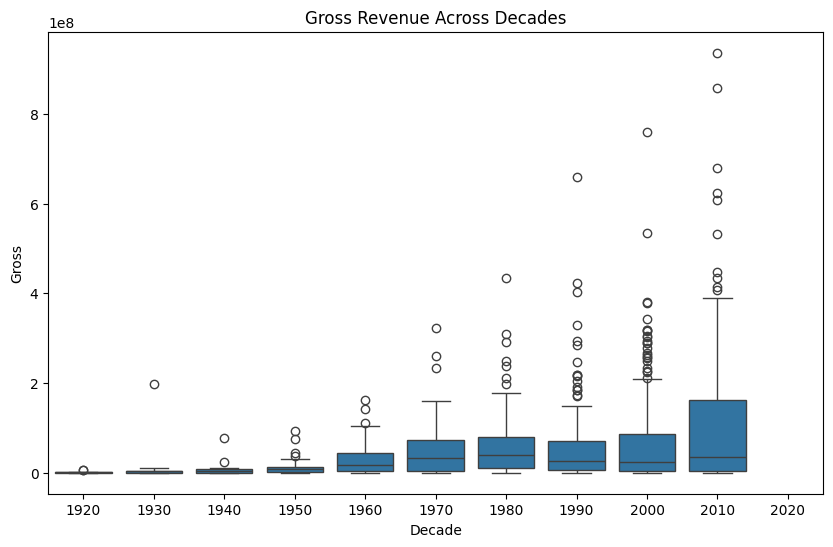

In [26]:
# Create a plot comparing gross revenue across decades.

plt.figure(figsize=(10, 6))
sns.boxplot(data=imdb, x="Decade", y="Gross")
plt.title("Gross Revenue Across Decades")
plt.xlabel("Decade")
plt.ylabel("Gross")
plt.show()


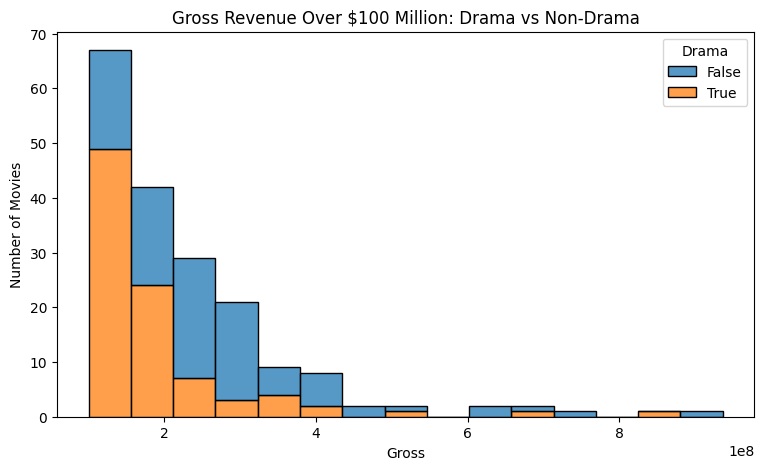

In [27]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

high_gross = imdb[imdb["Gross"] > 100000000]

plt.figure(figsize=(9, 5))
sns.histplot(data=high_gross, x="Gross", hue="Drama", bins=15, multiple="stack")
plt.title("Gross Revenue Over $100 Million: Drama vs Non-Drama")
plt.xlabel("Gross")
plt.ylabel("Number of Movies")
plt.show()


Question 1: Which movie certificates have the highest average IMDB rating?


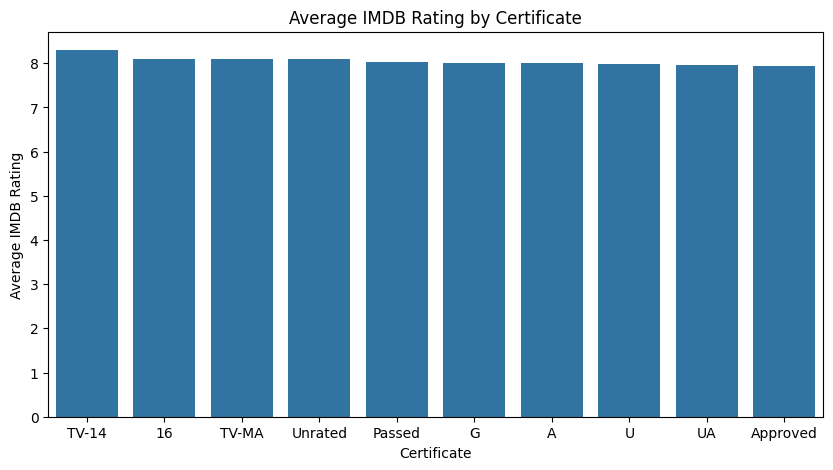

In [28]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1:

print("Question 1: Which movie certificates have the highest average IMDB rating?")
certificate_rating = imdb.groupby("Certificate")["IMDB_Rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=certificate_rating.index, y=certificate_rating.values)
plt.title("Average IMDB Rating by Certificate")
plt.xlabel("Certificate")
plt.ylabel("Average IMDB Rating")
plt.show()


Question 2: What are the most common movie runtimes?


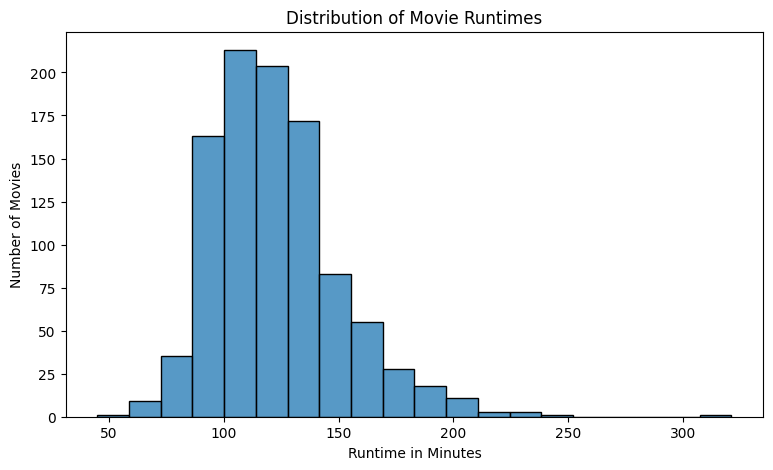

In [29]:
# Question 2:

print("Question 2: What are the most common movie runtimes?")

plt.figure(figsize=(9, 5))
sns.histplot(data=imdb, x="Runtime_min", bins=20)
plt.title("Distribution of Movie Runtimes")
plt.xlabel("Runtime in Minutes")
plt.ylabel("Number of Movies")
plt.show()
